# Global Config

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import paths

global config test

In [2]:
print(f"项目根目录: {paths.project_root}")
print(f"轨迹目录: {paths.shared_nvme}")
print(f"图片目录: {paths.figures_dir}")
print(f'data目录: {paths.data_dir}')

项目根目录: /root/SupercooledWater
轨迹目录: /root/shared_nvme
图片目录: /root/SupercooledWater/figures
data目录: /root/SupercooledWater/data


In [3]:
traj = paths.get_trajectory_path
fig = paths.get_figure_path
data = paths.get_data_path

## Module load

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict

from tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA
from tools.zeta_order_parameter import ZetaOrderParameter as ZOP

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Easy version check the S4

In [3]:
data = np.load("/root/s4_output/s4_results.npz")

S4_kz_all = data["S4_kz_all"]   # (n_lags, M)
kmags_z   = data["kmags_z"]
lag_times_fs = data["lag_times_fs"]

In [4]:
nonzero = kmags_z > 1e-10
k0_idx = np.where(nonzero)[0][0]   # smallest |k|

In [5]:
chi4_s4 = S4_kz_all[:, k0_idx]

In [6]:
# average over a few smallest k values
small_k_indices = np.where(nonzero)[0][:3]
chi4_s4 = S4_kz_all[:, small_k_indices].mean(axis=1)

In [7]:
tstar_idx = np.argmax(chi4_s4)
tstar_fs  = lag_times_fs[tstar_idx]

In [8]:
print(tstar_fs)

4725.0


# The original version of api

In [3]:
u = mda.Universe("/root/water/TIP4P/Ice/test/tip4p-ice-225K.data","/root/water/TIP4P/Ice/test/5e-6/traj_5e-6_225_100000.lammpstrj",format="LAMMPSDUMP")

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [4]:
hba = HBA(
        universe=u,
        donors_sel="type 1",
        hydrogens_sel="type 2",
        acceptors_sel="type 1",
        d_a_cutoff=3.5,
        h_d_a_angle_cutoff=30.0,
        update_selections=False, # Set True for flexible / protein systems
    )
hba.run(start=0, stop=None, step=1, verbose=True)

100%|██████████| 4001/4001 [09:19<00:00,  7.15it/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [7]:
hb = hba.results.hbonds          # shape (N_bonds_total, 6)

# Column layout:
#   hb[:, 0]  frame index
#   hb[:, 1]  donor atom index    (0-based)
#   hb[:, 2]  hydrogen atom index (0-based)
#   hb[:, 3]  acceptor atom index (0-based)
#   hb[:, 4]  D-A distance  (Å)
#   hb[:, 5]  H-D-A angle   (°)

print(f"Total H-bond observations : {len(hb)}")
print(f"Frames analysed           : {len(hba.frames)}")
print(f"Mean observations / frame : {len(hb)/len(hba.frames):.2f}")
print(f"Distance range            : {hb[:,4].min():.2f} – {hb[:,4].max():.2f} Å")
print(f"Angle range               : {hb[:,5].min():.2f} – {hb[:,5].max():.2f} °")

# Quick histogram of distances and angles
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(hb[:, 4], bins=50, color="steelblue", edgecolor="white")
axes[0].set(xlabel="D-A distance (Å)", ylabel="Count", title="Distance distribution(Shear)")
axes[1].hist(hb[:, 5], bins=50, color="tomato", edgecolor="white")
axes[1].set(xlabel="H-D-A angle (°)", ylabel="Count", title="Angle distribution(Shear)")
plt.tight_layout()
plt.savefig("hbond_distributions_shear.png", dpi=300)
plt.close()

Total H-bond observations : 32220002
Frames analysed           : 4001
Mean observations / frame : 8052.99
Distance range            : 2.45 – 3.50 Å
Angle range               : 0.00 – 30.00 °


In [ ]:
# ============================================================================
# 2.  H-bonds per molecule
# ============================================================================

# ---- 2a. Total H-bonds per frame (system-wide) ------------------------------
counts_per_frame = hba.count_by_time()        # shape (n_frames,)
# times_ps = hba.frames * u.trajectory.dt       # convert frames → ps
dt = 0.025  # ps
times_ps = hba.frames * dt   # convert frames -> ps

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(times_ps, counts_per_frame, lw=0.8, color="navy")
ax.axhline(counts_per_frame.mean(), color="tomato", ls="--",
           label=f"Mean = {counts_per_frame.mean():.1f}")
ax.set(xlabel="Time (ps)", ylabel="N(H-bond)", title="Total H-bonds vs. time")
ax.legend()
plt.tight_layout()
plt.savefig("hbonds_vs_time_shear.png", dpi=300)
plt.close()

# ---- 2b. Per-residue (per-molecule) average H-bond count --------------------
# Map atom index → residue index using the universe topology.
atom_to_resid = {atom.index: atom.resid for atom in u.atoms}

# Accumulate for donors and acceptors separately, then combine.
# A molecule can be simultaneously a donor in one bond and acceptor in another.
donor_counts    = defaultdict(int)  # {resid: total times appeared as donor}
acceptor_counts = defaultdict(int)  # {resid: total times appeared as acceptor}

for row in hb:
    d_resid = atom_to_resid[int(row[1])]
    a_resid = atom_to_resid[int(row[3])]
    donor_counts[d_resid]    += 1
    acceptor_counts[a_resid] += 1

n_frames    = len(hba.frames)
all_resids  = sorted(set(donor_counts) | set(acceptor_counts))

# Average number of H-bonds per molecule per frame
# (each molecule may be both donor and acceptor simultaneously)
per_mol_avg = {
    rid: (donor_counts.get(rid, 0) + acceptor_counts.get(rid, 0)) / n_frames
    for rid in all_resids
}

print("\nPer-residue average H-bond count (first 10 residues):")
for rid in all_resids[:10]:
    print(f"  residue {rid:5d}  avg H-bonds/frame = {per_mol_avg[rid]:.3f}")

# System-wide mean over all molecules
mean_hb_per_mol = np.mean(list(per_mol_avg.values()))
print(f"\nSystem mean H-bonds per molecule per frame: {mean_hb_per_mol:.3f}")




Per-residue average H-bond count (first 10 residues):
  residue     1  avg H-bonds/frame = 4.089
  residue     2  avg H-bonds/frame = 3.921
  residue     3  avg H-bonds/frame = 3.985
  residue     4  avg H-bonds/frame = 4.073
  residue     5  avg H-bonds/frame = 3.978
  residue     6  avg H-bonds/frame = 3.943
  residue     7  avg H-bonds/frame = 3.934
  residue     8  avg H-bonds/frame = 3.962
  residue     9  avg H-bonds/frame = 3.949
  residue    10  avg H-bonds/frame = 3.950

System mean H-bonds per molecule per frame: 3.932


In [10]:
# ---- 2c. Per-frame, per-molecule breakdown (useful for distributions) -------
# Build a {frame: {resid: count}} dict efficiently.
# This is the granular version – useful for computing distributions of
# "how many H-bonds does a single water molecule have at any instant?"

from collections import Counter

hb_count_by_frame_mol = defaultdict(Counter)  # {frame: Counter({resid: n})}
for row in hb:
    frame  = int(row[0])
    d_rid  = atom_to_resid[int(row[1])]
    a_rid  = atom_to_resid[int(row[3])]
    hb_count_by_frame_mol[frame][d_rid] += 1
    hb_count_by_frame_mol[frame][a_rid] += 1

# Flatten to a list of all per-molecule-per-frame counts
all_mol_counts = [
    count
    for frame_counter in hb_count_by_frame_mol.values()
    for count in frame_counter.values()
]

# Histogram: P(n) = probability of having exactly n H-bonds
max_n = max(all_mol_counts)
prob = np.bincount(all_mol_counts, minlength=max_n + 1) / len(all_mol_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(np.arange(len(prob)), prob, color="steelblue", edgecolor="white")
ax.set(xlabel="H-bonds per molecule", ylabel="Probability",
       title="P(n H-bonds) per molecule per frame")
plt.tight_layout()
plt.savefig("hbond_count_distribution_shear.png", dpi=300)
plt.close()


In [13]:
# ============================================================================
# 4.  Per-bond survival curve
# ============================================================================
# The lifetime() method averages over all bonds.  For a per-bond survival
# curve, build I_{dha}(t) directly from the results array.

# Build a boolean array  presence[bond_label, frame_index]
# Bond label = frozenset({hydrogen_idx, acceptor_idx})  (same convention as lifetime())

from itertools import product as iproduct

frame_index = {f: i for i, f in enumerate(hba.frames)}

# Collect unique bond labels
bond_labels = list({frozenset((int(r[2]), int(r[3]))) for r in hb})
bond_to_row = {label: i for i, label in enumerate(bond_labels)}

presence = np.zeros((len(bond_labels), len(hba.frames)), dtype=bool)
for row in hb:
    fi     = frame_index[int(row[0])]
    label  = frozenset((int(row[2]), int(row[3])))
    presence[bond_to_row[label], fi] = True

# Survival probability: fraction of bonds that persist for at least τ frames
# after they were first observed to be present.
max_tau = min(200000, len(hba.frames) - 1)
survival = np.zeros(max_tau + 1)
survival[0] = 1.0

for tau in range(1, max_tau + 1):
    # For each bond, count frames t₀ where it was present AND also at t₀+tau
    n_start  = presence[:, : len(hba.frames) - tau].sum()
    n_persist = (presence[:, : len(hba.frames) - tau] &
                 presence[:, tau : len(hba.frames)]).sum()
    survival[tau] = n_persist / n_start if n_start > 0 else 0.0

dt = 0.025  # ps
tau_surv_ps = np.arange(max_tau + 1) * dt
# tau_surv_ps = np.arange(max_tau + 1) * u.trajectory.dt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_surv_ps, survival, color="darkorange", lw=1.5)
ax.set(xlabel="Lag time (ps)", ylabel="Survival probability S(t)",
       title="H-bond survival curve", ylim=(0, 1.05))
plt.tight_layout()
plt.savefig("hbond_survival_shear.png", dpi=300)
plt.close()

In [17]:
# ============================================================================
# 5.  H-bond network: formation/breaking events
# ============================================================================

# ---- 5a. Count events per frame --------------------------------------------
events_arr = hba.count_hbond_events()   # shape (n_frames-1, 3): [frame, formed, broken]

fig, ax = plt.subplots(figsize=(9, 3))
frame_labels = events_arr[:, 0] * dt
# frame_labels = events_arr[:, 0] * u.trajectory.dt
ax.plot(frame_labels, events_arr[:, 1], label="Formed",  color="green",  lw=0.8)
ax.plot(frame_labels, events_arr[:, 2], label="Broken",  color="crimson", lw=0.8)
ax.set(xlabel="Time (ps)", ylabel="Events / frame", title="H-bond formation & breaking")
ax.legend()
plt.tight_layout()
plt.savefig("hbond_events_shear.png", dpi=300)
plt.close()

print(f"\nMean formation rate : {events_arr[:,1].mean():.2f} bonds/frame")
print(f"Mean breaking  rate : {events_arr[:,2].mean():.2f} bonds/frame")

# ---- 5b. Detailed changes dictionary ---------------------------------------
changes = hba.get_connectivity_changes()
# changes[frame] = {"formed": [(d,h,a), ...], "broken": [(d,h,a), ...]}

# Example: print the first frame that had more than 5 bond-breaking events
for frame, ch in sorted(changes.items()):
    if len(ch["broken"]) > 5:
        print(f"\nFrame {frame}: {len(ch['broken'])} bonds broke")
        for d, h, a in ch["broken"][:3]:
            donor_name = u.atoms[d].name if hasattr(u.atoms[d], 'name') else str(d)
            acceptor_name = u.atoms[a].name if hasattr(u.atoms[a], 'name') else str(a)
            print(f"  donor={d} ({donor_name}), H={h}, acceptor={a} ({acceptor_name})")
        break

# ---- 5c. Network snapshot for a single frame --------------------------------
snapshot_frame = hba.frames[len(hba.frames) // 2]   # middle frame
network = hba.get_network_at_frame(snapshot_frame)
print(f"\nNetwork at frame {snapshot_frame}: "
      f"{sum(len(v) for v in network.values())} directed bonds, "
      f"{len(network)} unique donors")

# Optional: export as adjacency matrix (for small subsystems)
water_indices = u.select_atoms("type 1").indices
if len(water_indices) <= 500:
    mat = hba.get_hbond_matrix(snapshot_frame, atom_indices=water_indices)
    np.save("hbond_adjacency_matrix_shear.npy", mat)
    print(f"Adjacency matrix saved: {mat.shape}, {mat.sum()} bonds")



Mean formation rate : 120.94 bonds/frame
Mean breaking  rate : 120.94 bonds/frame

Frame 1: 116 bonds broke
  donor=6246 (6246), H=6247, acceptor=7893 (7893)
  donor=4023 (4023), H=4025, acceptor=5118 (5118)
  donor=10983 (10983), H=10985, acceptor=3750 (3750)

Network at frame 2000: 8059 directed bonds, 4096 unique donors


In [18]:
# ============================================================================
# 6.  Reorientation dynamics: acceptor-switch (jump) events
# ============================================================================

switches = hba.find_hbond_switches()    # list of dicts, one per switch event
print(f"\nTotal acceptor-switch events detected: {len(switches)}")

if len(switches) > 0:
    jump_angles = np.array([ev["jump_angle_deg"] for ev in switches])
    jump_frames = np.array([ev["frame"]           for ev in switches])
    # jump_times  = jump_frames * u.trajectory.dt
    jump_times = jump_frames * dt

    print(f"Jump angle: mean={jump_angles.mean():.1f}°, "
          f"std={jump_angles.std():.1f}°, "
          f"median={np.median(jump_angles):.1f}°")

    # Distribution of jump angles
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(jump_angles, bins=40, color="mediumpurple", edgecolor="white",
            density=True)
    ax.axvline(jump_angles.mean(), color="black", ls="--",
               label=f"Mean = {jump_angles.mean():.1f}°")
    ax.set(xlabel="Jump angle (°)", ylabel="Probability density",
           title="Distribution of H-bond acceptor-switch angles")
    ax.legend()
    plt.tight_layout()
    plt.savefig("jump_angle_distribution_shear.png", dpi=300)
    plt.close()

    # Rate of jumps vs. time
    jump_rate, bin_edges = np.histogram(
        jump_times,
        bins=np.arange(jump_times.min(), jump_times.max(), 1.0)  # 1 ps bins
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(bin_centers, jump_rate, color="purple", lw=0.9)
    ax.set(xlabel="Time (ps)", ylabel="Jumps / ps",
           title="H-bond acceptor-switch rate")
    plt.tight_layout()
    plt.savefig("jump_rate_vs_time_shear.png", dpi=300)
    plt.close()

    # Example: print the 3 largest jumps
    top3 = sorted(switches, key=lambda e: e["jump_angle_deg"], reverse=True)[:3]
    print("\nLargest jump events:")
    for ev in top3:
        print(f"  frame={ev['frame']:5d}  donor={ev['donor_idx']}  "
              f"old_acc={ev['old_acceptor_idx']}  "
              f"new_acc={ev['new_acceptor_idx']}  "
              f"angle={ev['jump_angle_deg']:.1f}°")

# # ============================================================================
# # 7.  O-H rotational autocorrelation C_2(t)
# # ============================================================================
# # Pick a representative water molecule and compute C_2(t) for each O-H bond.
# # In practice you would average over all molecules; here we show one as a demo.

# # Find a molecule that is H-bonded for most of the trajectory
# mol_hb_count = {
#     rid: donor_counts.get(rid, 0) + acceptor_counts.get(rid, 0)
#     for rid in all_resids
# }
# most_hbonded_resid = max(mol_hb_count, key=mol_hb_count.get)
# mol = u.select_atoms(f"resid {most_hbonded_resid} and resname SOL")

# # Identify the OW and HW1/HW2 by name
# try:
#     ow_idx  = mol.select_atoms("name OW").indices[0]
#     hw1_idx = mol.select_atoms("name HW1").indices[0]
#     hw2_idx = mol.select_atoms("name HW2").indices[0]
# except (IndexError, AttributeError):
#     # Fallback: pick atoms by mass if names differ
#     ow_idx  = mol.atoms[np.argmax(mol.masses)].index
#     hw1_idx = mol.atoms[mol.masses < 1.1][0].index
#     hw2_idx = mol.atoms[mol.masses < 1.1][1].index

# tau_array, acf_hw1 = hba.compute_oh_acf(ow_idx, hw1_idx, l=2)
# tau_array, acf_hw2 = hba.compute_oh_acf(ow_idx, hw2_idx, l=2)

# acf_avg = 0.5 * (acf_hw1 + acf_hw2)    # average over both O-H bonds of the molecule
# tau_ps_acf = tau_array * u.trajectory.dt

# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(tau_ps_acf, acf_hw1, lw=0.8, alpha=0.6, label="HW1")
# ax.plot(tau_ps_acf, acf_hw2, lw=0.8, alpha=0.6, label="HW2")
# ax.plot(tau_ps_acf, acf_avg, lw=2.0, color="black", label="Average")
# ax.axhline(0, color="grey", lw=0.5)
# ax.set(xlabel="Lag time (ps)", ylabel=r"$C_2(t)$",
#        title=f"O-H rotational ACF – residue {most_hbonded_resid}")
# ax.legend()
# plt.tight_layout()
# plt.savefig("oh_acf.png", dpi=300)
# plt.close()

# # Extract τ_OH (time for C_2 to decay to 1/e)
# try:
#     idx_1e = np.where(acf_avg < 1.0 / np.e)[0][0]
#     tau_OH = tau_ps_acf[idx_1e]
#     print(f"\nτ_OH (1/e decay) ≈ {tau_OH:.2f} ps  [residue {most_hbonded_resid}]")
# except IndexError:
#     print("\nC_2(t) did not decay to 1/e within the trajectory length.")

# ============================================================================
# 8.  Saving and loading results
# ============================================================================

# ---- Save -------------------------------------------------------------------
np.save("hbonds_results_shear.npy", hba.results.hbonds)
np.savetxt(
    "hbonds_results_shear.csv",
    hba.results.hbonds,
    delimiter=",",
    header="frame,donor_idx,hydrogen_idx,acceptor_idx,da_distance_A,hda_angle_deg",
    comments="",
)

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt



Total acceptor-switch events detected: 118605
Jump angle: mean=58.6°, std=28.4°, median=55.3°

Largest jump events:
  frame= 3761  donor=417  old_acc=10566  new_acc=7179  angle=179.8°
  frame= 3149  donor=492  old_acc=7047  new_acc=10398  angle=178.6°
  frame= 1354  donor=3948  old_acc=2697  new_acc=1191  angle=178.5°


OSError: [Errno 28] No space left on device

In [6]:
events = hba.count_hbond_events()

In [7]:
print(events)

[[   1  134  143]
 [   2  143  151]
 [   3  159  138]
 ...
 [2498  156  159]
 [2499  159  155]
 [2500  161  164]]


In [2]:
"""
Complete H-bond Analysis Pipeline
===================================
Using custom_hbond_analysis.py

Covers
------
  0.  Setup & running the analysis
  1.  Raw results inspection
  2.  H-bonds per molecule (per-residue counts, time-averaged and per-frame)
  3.  H-bond persistence time (lifetime autocorrelation, with intermittency)
  4.  Per-bond survival curve (fraction still intact vs. lag time)
  5.  H-bond network: adjacency, formation/breaking events
  6.  Reorientation dynamics: acceptor-switch (jump) events & jump-angle distribution
  7.  O-H rotational autocorrelation C_2(t)
  8.  Saving / loading results

All code blocks are self-contained given the variables from the block above.
Replace the file paths and selection strings to match your own system.
"""

# ============================================================================
# 0.  Setup – load universe, build and run the analysis
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from collections import defaultdict

from water.tools.custom_hbond_analysis import HydrogenBondAnalysis as HBA

# ---- Load your system -------------------------------------------------------
# Use a topology that carries bond information (TPR, PSF, PRMTOP …) so that
# donor-hydrogen pairs are resolved from the bond graph rather than a distance
# heuristic.  PDB works too if you provide donors_sel explicitly.

u = mda.Universe("/root/water/TIP4P/Ice/test/tip4p-ice-225K.data","/root/water/TIP4P/Ice/225/dump_225_test.lammpstrj",format="LAMMPSDUMP",dt=0.2)

# ---- Instantiate ------------------------------------------------------------
# Pure TIP4P/2005 water example; adjust resname / atom names for your force field.
# Common alternatives:
#   TIP3P   donors_sel="resname TIP3 and name OH2"
#           hydrogens_sel="resname TIP3 and name H1 H2"
#           acceptors_sel="resname TIP3 and name OH2"
#   SPC/E   donors_sel="resname SOL and name OW"
#           hydrogens_sel="resname SOL and name HW1 HW2"
#           acceptors_sel="resname SOL and name OW"

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run(start=0, stop=None, step=1, verbose=True)

# ============================================================================
# 1.  Raw results inspection
# ============================================================================

hb = hba.results.hbonds          # shape (N_bonds_total, 6)

# Column layout:
#   hb[:, 0]  frame index
#   hb[:, 1]  donor atom index    (0-based)
#   hb[:, 2]  hydrogen atom index (0-based)
#   hb[:, 3]  acceptor atom index (0-based)
#   hb[:, 4]  D-A distance  (Å)
#   hb[:, 5]  H-D-A angle   (°)

print(f"Total H-bond observations : {len(hb)}")
print(f"Frames analysed           : {len(hba.frames)}")
print(f"Mean observations / frame : {len(hb)/len(hba.frames):.2f}")
print(f"Distance range            : {hb[:,4].min():.2f} – {hb[:,4].max():.2f} Å")
print(f"Angle range               : {hb[:,5].min():.2f} – {hb[:,5].max():.2f} °")

# Quick histogram of distances and angles
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(hb[:, 4], bins=50, color="steelblue", edgecolor="white")
axes[0].set(xlabel="D-A distance (Å)", ylabel="Count", title="Distance distribution")
axes[1].hist(hb[:, 5], bins=50, color="tomato", edgecolor="white")
axes[1].set(xlabel="H-D-A angle (°)", ylabel="Count", title="Angle distribution")
plt.tight_layout()
plt.savefig("hbond_distributions.png", dpi=300)
plt.close()

# ============================================================================
# 2.  H-bonds per molecule
# ============================================================================

# ---- 2a. Total H-bonds per frame (system-wide) ------------------------------
counts_per_frame = hba.count_by_time()        # shape (n_frames,)
times_ps = hba.frames * u.trajectory.dt       # convert frames → ps

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(times_ps, counts_per_frame, lw=0.8, color="navy")
ax.axhline(counts_per_frame.mean(), color="tomato", ls="--",
           label=f"Mean = {counts_per_frame.mean():.1f}")
ax.set(xlabel="Time (ps)", ylabel="N(H-bond)", title="Total H-bonds vs. time")
ax.legend()
plt.tight_layout()
plt.savefig("hbonds_vs_time.png", dpi=300)
plt.close()

# ---- 2b. Per-residue (per-molecule) average H-bond count --------------------
# Map atom index → residue index using the universe topology.
atom_to_resid = {atom.index: atom.resid for atom in u.atoms}

# Accumulate for donors and acceptors separately, then combine.
# A molecule can be simultaneously a donor in one bond and acceptor in another.
donor_counts    = defaultdict(int)  # {resid: total times appeared as donor}
acceptor_counts = defaultdict(int)  # {resid: total times appeared as acceptor}

for row in hb:
    d_resid = atom_to_resid[int(row[1])]
    a_resid = atom_to_resid[int(row[3])]
    donor_counts[d_resid]    += 1
    acceptor_counts[a_resid] += 1

n_frames    = len(hba.frames)
all_resids  = sorted(set(donor_counts) | set(acceptor_counts))

# Average number of H-bonds per molecule per frame
# (each molecule may be both donor and acceptor simultaneously)
per_mol_avg = {
    rid: (donor_counts.get(rid, 0) + acceptor_counts.get(rid, 0)) / n_frames
    for rid in all_resids
}

print("\nPer-residue average H-bond count (first 10 residues):")
for rid in all_resids[:10]:
    print(f"  residue {rid:5d}  avg H-bonds/frame = {per_mol_avg[rid]:.3f}")

# System-wide mean over all molecules
mean_hb_per_mol = np.mean(list(per_mol_avg.values()))
print(f"\nSystem mean H-bonds per molecule per frame: {mean_hb_per_mol:.3f}")

# ---- 2c. Per-frame, per-molecule breakdown (useful for distributions) -------
# Build a {frame: {resid: count}} dict efficiently.
# This is the granular version – useful for computing distributions of
# "how many H-bonds does a single water molecule have at any instant?"

from collections import Counter

hb_count_by_frame_mol = defaultdict(Counter)  # {frame: Counter({resid: n})}
for row in hb:
    frame  = int(row[0])
    d_rid  = atom_to_resid[int(row[1])]
    a_rid  = atom_to_resid[int(row[3])]
    hb_count_by_frame_mol[frame][d_rid] += 1
    hb_count_by_frame_mol[frame][a_rid] += 1

# Flatten to a list of all per-molecule-per-frame counts
all_mol_counts = [
    count
    for frame_counter in hb_count_by_frame_mol.values()
    for count in frame_counter.values()
]

# Histogram: P(n) = probability of having exactly n H-bonds
max_n = max(all_mol_counts)
prob = np.bincount(all_mol_counts, minlength=max_n + 1) / len(all_mol_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(np.arange(len(prob)), prob, color="steelblue", edgecolor="white")
ax.set(xlabel="H-bonds per molecule", ylabel="Probability",
       title="P(n H-bonds) per molecule per frame")
plt.tight_layout()
plt.savefig("hbond_count_distribution.png", dpi=300)
plt.close()

# # ============================================================================
# # 3.  H-bond persistence time (lifetime autocorrelation)
# # ============================================================================

# # The lifetime is computed via the autocorrelation of the H-bond population
# # indicator function  I(t)  for each bond.
# #
# # hba.lifetime() wraps MDAnalysis' autocorrelation() and correct_intermittency().
# #
# # intermittency=0 → strict continuous criterion (bond must be present every frame)
# # intermittency=k → bond may be absent for at most k consecutive frames
# #                   (useful when dt is small or when using coarser frame spacing)

# tau_max = 4000   # frames; convert to ps by multiplying by dt

# result_cont = hba.lifetime(tau_max=tau_max, intermittency=0)
# result_int2 = hba.lifetime(tau_max=tau_max, intermittency=2)

# # result shape: (2, tau_max) – row 0: tau, row 1: C(tau)
# tau_frames = result_cont[0]           # lag times in frames
# tau_ps     = tau_frames * u.trajectory.dt

# C_cont = result_cont[1]
# C_int2 = result_int2[1]

# # Fit a bi-exponential decay to extract fast (τ_fast) and slow (τ_slow) timescales.
# from scipy.optimize import curve_fit

# def biexp(t, A, tau1, B, tau2):
#     return A * np.exp(-t / tau1) + B * np.exp(-t / tau2)

# try:
#     # Initial guess: A=0.5, τ1=1 ps, B=0.5, τ2=5 ps
#     dt_ps = u.trajectory.dt
#     popt, _ = curve_fit(
#         biexp, tau_ps, C_cont,
#         p0=[0.5, 1.0, 0.5, 5.0],
#         bounds=([0, 0, 0, 0], [1, 100, 1, 1000]),
#         maxfev=10000,
#     )
#     A, tau1, B, tau2 = popt
#     tau_avg = A * tau1 + B * tau2   # amplitude-weighted mean lifetime
#     print(f"\nBi-exponential lifetime fit:")
#     print(f"  fast component : A={A:.3f}, τ={tau1:.2f} ps")
#     print(f"  slow component : B={B:.3f}, τ={tau2:.2f} ps")
#     print(f"  mean lifetime  : {tau_avg:.2f} ps")
#     fitted = biexp(tau_ps, *popt)
#     fit_available = True
# except RuntimeError:
#     print("Bi-exponential fit did not converge – increase tau_max or adjust p0.")
#     fit_available = False

# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(tau_ps, C_cont, label="Continuous (intermittency=0)", color="navy")
# ax.plot(tau_ps, C_int2, label="Intermittency=2",             color="tomato", ls="--")
# if fit_available:
#     ax.plot(tau_ps, fitted, label=f"Bi-exp fit (τ_avg={tau_avg:.1f} ps)",
#             color="black", ls=":", lw=2)
# ax.set(xlabel="Lag time (ps)", ylabel="C(t)", title="H-bond lifetime autocorrelation")
# ax.legend()
# plt.tight_layout()
# plt.savefig("hbond_lifetime_acf.png", dpi=300)
# plt.close()

# ============================================================================
# 4.  Per-bond survival curve
# ============================================================================
# The lifetime() method averages over all bonds.  For a per-bond survival
# curve, build I_{dha}(t) directly from the results array.

# Build a boolean array  presence[bond_label, frame_index]
# Bond label = frozenset({hydrogen_idx, acceptor_idx})  (same convention as lifetime())

from itertools import product as iproduct

frame_index = {f: i for i, f in enumerate(hba.frames)}

# Collect unique bond labels
bond_labels = list({frozenset((int(r[2]), int(r[3]))) for r in hb})
bond_to_row = {label: i for i, label in enumerate(bond_labels)}

presence = np.zeros((len(bond_labels), len(hba.frames)), dtype=bool)
for row in hb:
    fi     = frame_index[int(row[0])]
    label  = frozenset((int(row[2]), int(row[3])))
    presence[bond_to_row[label], fi] = True

# Survival probability: fraction of bonds that persist for at least τ frames
# after they were first observed to be present.
max_tau = min(200, len(hba.frames) - 1)
survival = np.zeros(max_tau + 1)
survival[0] = 1.0

for tau in range(1, max_tau + 1):
    # For each bond, count frames t₀ where it was present AND also at t₀+tau
    n_start  = presence[:, : len(hba.frames) - tau].sum()
    n_persist = (presence[:, : len(hba.frames) - tau] &
                 presence[:, tau : len(hba.frames)]).sum()
    survival[tau] = n_persist / n_start if n_start > 0 else 0.0

tau_surv_ps = np.arange(max_tau + 1) * u.trajectory.dt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tau_surv_ps, survival, color="darkorange", lw=1.5)
ax.set(xlabel="Lag time (ps)", ylabel="Survival probability S(t)",
       title="H-bond survival curve", ylim=(0, 1.05))
plt.tight_layout()
plt.savefig("hbond_survival.png", dpi=300)
plt.close()

# ============================================================================
# 5.  H-bond network: formation/breaking events
# ============================================================================

# ---- 5a. Count events per frame --------------------------------------------
events_arr = hba.count_hbond_events()   # shape (n_frames-1, 3): [frame, formed, broken]

fig, ax = plt.subplots(figsize=(9, 3))
frame_labels = events_arr[:, 0] * u.trajectory.dt
ax.plot(frame_labels, events_arr[:, 1], label="Formed",  color="green",  lw=0.8)
ax.plot(frame_labels, events_arr[:, 2], label="Broken",  color="crimson", lw=0.8)
ax.set(xlabel="Time (ps)", ylabel="Events / frame", title="H-bond formation & breaking")
ax.legend()
plt.tight_layout()
plt.savefig("hbond_events.png", dpi=300)
plt.close()

print(f"\nMean formation rate : {events_arr[:,1].mean():.2f} bonds/frame")
print(f"Mean breaking  rate : {events_arr[:,2].mean():.2f} bonds/frame")

# ---- 5b. Detailed changes dictionary ---------------------------------------
changes = hba.get_connectivity_changes()
# changes[frame] = {"formed": [(d,h,a), ...], "broken": [(d,h,a), ...]}

# Example: print the first frame that had more than 5 bond-breaking events
for frame, ch in sorted(changes.items()):
    if len(ch["broken"]) > 5:
        print(f"\nFrame {frame}: {len(ch['broken'])} bonds broke")
        for d, h, a in ch["broken"][:3]:
            donor_name = u.atoms[d].name if hasattr(u.atoms[d], 'name') else str(d)
            acceptor_name = u.atoms[a].name if hasattr(u.atoms[a], 'name') else str(a)
            print(f"  donor={d} ({donor_name}), H={h}, acceptor={a} ({acceptor_name})")
            # print(f"  donor={d} ({u.atoms[d].name}), "
            #       f"H={h}, acceptor={a} ({u.atoms[a].name})")
        break

# ---- 5c. Network snapshot for a single frame --------------------------------
snapshot_frame = hba.frames[len(hba.frames) // 2]   # middle frame
network = hba.get_network_at_frame(snapshot_frame)
print(f"\nNetwork at frame {snapshot_frame}: "
      f"{sum(len(v) for v in network.values())} directed bonds, "
      f"{len(network)} unique donors")

# Optional: export as adjacency matrix (for small subsystems)
water_indices = u.select_atoms("type 1").indices
if len(water_indices) <= 500:
    mat = hba.get_hbond_matrix(snapshot_frame, atom_indices=water_indices)
    np.save("hbond_adjacency_matrix.npy", mat)
    print(f"Adjacency matrix saved: {mat.shape}, {mat.sum()} bonds")

# ============================================================================
# 6.  Reorientation dynamics: acceptor-switch (jump) events
# ============================================================================

switches = hba.find_hbond_switches()    # list of dicts, one per switch event
print(f"\nTotal acceptor-switch events detected: {len(switches)}")

if len(switches) > 0:
    jump_angles = np.array([ev["jump_angle_deg"] for ev in switches])
    jump_frames = np.array([ev["frame"]           for ev in switches])
    jump_times  = jump_frames * u.trajectory.dt

    print(f"Jump angle: mean={jump_angles.mean():.1f}°, "
          f"std={jump_angles.std():.1f}°, "
          f"median={np.median(jump_angles):.1f}°")

    # Distribution of jump angles
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(jump_angles, bins=40, color="mediumpurple", edgecolor="white",
            density=True)
    ax.axvline(jump_angles.mean(), color="black", ls="--",
               label=f"Mean = {jump_angles.mean():.1f}°")
    ax.set(xlabel="Jump angle (°)", ylabel="Probability density",
           title="Distribution of H-bond acceptor-switch angles")
    ax.legend()
    plt.tight_layout()
    plt.savefig("jump_angle_distribution.png", dpi=300)
    plt.close()

    # Rate of jumps vs. time
    jump_rate, bin_edges = np.histogram(
        jump_times,
        bins=np.arange(jump_times.min(), jump_times.max(), 1.0)  # 1 ps bins
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(bin_centers, jump_rate, color="purple", lw=0.9)
    ax.set(xlabel="Time (ps)", ylabel="Jumps / ps",
           title="H-bond acceptor-switch rate")
    plt.tight_layout()
    plt.savefig("jump_rate_vs_time.png", dpi=300)
    plt.close()

    # Example: print the 3 largest jumps
    top3 = sorted(switches, key=lambda e: e["jump_angle_deg"], reverse=True)[:3]
    print("\nLargest jump events:")
    for ev in top3:
        print(f"  frame={ev['frame']:5d}  donor={ev['donor_idx']}  "
              f"old_acc={ev['old_acceptor_idx']}  "
              f"new_acc={ev['new_acceptor_idx']}  "
              f"angle={ev['jump_angle_deg']:.1f}°")

# # ============================================================================
# # 7.  O-H rotational autocorrelation C_2(t)
# # ============================================================================
# # Pick a representative water molecule and compute C_2(t) for each O-H bond.
# # In practice you would average over all molecules; here we show one as a demo.

# # Find a molecule that is H-bonded for most of the trajectory
# mol_hb_count = {
#     rid: donor_counts.get(rid, 0) + acceptor_counts.get(rid, 0)
#     for rid in all_resids
# }
# most_hbonded_resid = max(mol_hb_count, key=mol_hb_count.get)
# mol = u.select_atoms(f"resid {most_hbonded_resid} and resname SOL")

# # Identify the OW and HW1/HW2 by name
# try:
#     ow_idx  = mol.select_atoms("name OW").indices[0]
#     hw1_idx = mol.select_atoms("name HW1").indices[0]
#     hw2_idx = mol.select_atoms("name HW2").indices[0]
# except (IndexError, AttributeError):
#     # Fallback: pick atoms by mass if names differ
#     ow_idx  = mol.atoms[np.argmax(mol.masses)].index
#     hw1_idx = mol.atoms[mol.masses < 1.1][0].index
#     hw2_idx = mol.atoms[mol.masses < 1.1][1].index

# tau_array, acf_hw1 = hba.compute_oh_acf(ow_idx, hw1_idx, l=2)
# tau_array, acf_hw2 = hba.compute_oh_acf(ow_idx, hw2_idx, l=2)

# acf_avg = 0.5 * (acf_hw1 + acf_hw2)    # average over both O-H bonds of the molecule
# tau_ps_acf = tau_array * u.trajectory.dt

# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(tau_ps_acf, acf_hw1, lw=0.8, alpha=0.6, label="HW1")
# ax.plot(tau_ps_acf, acf_hw2, lw=0.8, alpha=0.6, label="HW2")
# ax.plot(tau_ps_acf, acf_avg, lw=2.0, color="black", label="Average")
# ax.axhline(0, color="grey", lw=0.5)
# ax.set(xlabel="Lag time (ps)", ylabel=r"$C_2(t)$",
#        title=f"O-H rotational ACF – residue {most_hbonded_resid}")
# ax.legend()
# plt.tight_layout()
# plt.savefig("oh_acf.png", dpi=300)
# plt.close()

# # Extract τ_OH (time for C_2 to decay to 1/e)
# try:
#     idx_1e = np.where(acf_avg < 1.0 / np.e)[0][0]
#     tau_OH = tau_ps_acf[idx_1e]
#     print(f"\nτ_OH (1/e decay) ≈ {tau_OH:.2f} ps  [residue {most_hbonded_resid}]")
# except IndexError:
#     print("\nC_2(t) did not decay to 1/e within the trajectory length.")

# ============================================================================
# 8.  Saving and loading results
# ============================================================================

# ---- Save -------------------------------------------------------------------
np.save("hbonds_results.npy", hba.results.hbonds)
# np.savetxt(
#     "hbonds_results.csv",
#     hba.results.hbonds,
#     delimiter=",",
#     header="frame,donor_idx,hydrogen_idx,acceptor_idx,da_distance_A,hda_angle_deg",
#     comments="",
# )

# ---- Reload and inspect without re-running the analysis --------------------
# import numpy as np
# hb_loaded = np.load("hbonds_results.npy")
#
# n_frames_saved = int(hb_loaded[:, 0].max() - hb_loaded[:, 0].min() + 1)
# print(f"Loaded {len(hb_loaded)} H-bond records over {n_frames_saved} frames")

# print("\nAll outputs written:")
# for fname in [
#     "hbond_distributions.png",
#     "hbonds_vs_time.png",
#     "hbond_count_distribution.png",
#     "hbond_lifetime_acf.png",
#     "hbond_survival.png",
#     "hbond_events.png",
#     "jump_angle_distribution.png",
#     "jump_rate_vs_time.png",
#     "oh_acf.png",
#     "hbonds_results.npy",
#     "hbonds_results.csv",
# ]:
#     print(f"  {fname}")

100%|██████████| 2501/2501 [04:32<00:00,  9.17it/s]


Total H-bond observations : 20257054
Frames analysed           : 2501
Mean observations / frame : 8099.58
Distance range            : 2.44 – 3.50 Å
Angle range               : 0.00 – 30.00 °

Per-residue average H-bond count (first 10 residues):
  residue     1  avg H-bonds/frame = 3.830
  residue     2  avg H-bonds/frame = 3.932
  residue     3  avg H-bonds/frame = 3.844
  residue     4  avg H-bonds/frame = 3.741
  residue     5  avg H-bonds/frame = 4.054
  residue     6  avg H-bonds/frame = 4.009
  residue     7  avg H-bonds/frame = 3.993
  residue     8  avg H-bonds/frame = 3.929
  residue     9  avg H-bonds/frame = 3.942
  residue    10  avg H-bonds/frame = 4.022

System mean H-bonds per molecule per frame: 3.955

Mean formation rate : 149.53 bonds/frame
Mean breaking  rate : 149.53 bonds/frame

Frame 1: 143 bonds broke
  donor=5076 (5076), H=5078, acceptor=4317 (4317)
  donor=1104 (1104), H=1106, acceptor=7932 (7932)
  donor=2922 (2922), H=2923, acceptor=2475 (2475)

Network at fr

## Begin $\zeta$ analysis

In [5]:
u = mda.Universe(traj("tip4p-ice-225K.data"),traj("traj_5e-6_225_100000.lammpstrj"),format="LAMMPSDUMP",dt=0.025)

# ---- Instantiate ------------------------------------------------------------
# Pure TIP4P/2005 water example; adjust resname / atom names for your force field.
# Common alternatives:
#   TIP3P   donors_sel="resname TIP3 and name OH2"
#           hydrogens_sel="resname TIP3 and name H1 H2"
#           acceptors_sel="resname TIP3 and name OH2"
#   SPC/E   donors_sel="resname SOL and name OW"
#           hydrogens_sel="resname SOL and name HW1 HW2"
#           acceptors_sel="resname SOL and name OW"

hba = HBA(
    universe=u,
    donors_sel="type 1",
    hydrogens_sel="type 2",
    acceptors_sel="type 1",
    d_a_cutoff=3.5,          # Å – donor-to-acceptor heavy-atom distance
    h_d_a_angle_cutoff=30.0, # °  – angle at the donor (H-D-A < 30°)
    update_selections=False, # Set True for flexible / protein systems
)

# ---- Run --------------------------------------------------------------------
# start/stop/step follow MDAnalysis convention (frame indices, not time).
# Omit them to analyse every frame.
hba.run()

FileNotFoundError: [Errno 2] No such file or directory: '/root/shared_nvme/tip4p-ice-225K.data'

In [ ]:
# ---- Zeta analysis ----------------------------------------------------------
# shell_cutoff > d_a_cutoff to ensure at least one non-HB neighbor is found.
# 6.0 Å spans comfortably into the first-shell / second-shell boundary in water.
zop = ZOP(
    hba=hba,
    central_sel="type 1",
    shell_cutoff=6.0,
)
zop.run(verbose=True)
 
times_ps        = zop.results.times          # shape (n_frames,)
central_indices = zop.results.central_indices  # OW atom indices

100%|██████████| 4001/4001 [14:10<00:00,  4.71it/s]


In [3]:
# ============================================================================
# 5.  P(ζ) probability distribution
# ============================================================================
 
bin_centers, prob_density = zop.get_zeta_distribution(bins=120, range_=(-1.0, 1.5))
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_centers, prob_density, color="royalblue", lw=2.0)
# ax.fill_between(bin_centers, prob_density,
#                 where=(bin_centers >= 0), alpha=0.3, color="mediumseagreen",
#                 label=f"ζ > 0  (tetrahedral,  f={f_tet_global:.2f})")
# ax.fill_between(bin_centers, prob_density,
#                 where=(bin_centers < 0),  alpha=0.3, color="tomato",
#                 label=f"ζ < 0  (distorted,    f={1-f_tet_global:.2f})")
# ax.axvline(0, color="black", lw=1.0, ls="--")
# ax.axvline(global_mean, color="navy", lw=1.2, ls="-.",
#            label=f"Mean ζ = {global_mean:.3f} Å")
ax.set(
    xlabel="ζ (Å)",
    ylabel="P(ζ)  (Å⁻¹)",
    title="Probability distribution of the zeta order parameter",
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("zeta_distribution_shear.png", dpi=300)
plt.close()
 
# Numerical summary statistics of P(ζ)
flat_zeta = zop.results.zeta.ravel()
flat_zeta = flat_zeta[~np.isnan(flat_zeta)]
print(f"\n[5] P(ζ) statistics:")
print(f"    Mean   = {flat_zeta.mean():.4f} Å")
print(f"    Std    = {flat_zeta.std():.4f} Å")
print(f"    Skew   = {float(np.mean(((flat_zeta - flat_zeta.mean())/flat_zeta.std())**3)):.4f}")
print(f"    Median = {np.median(flat_zeta):.4f} Å")
print(f"    P10    = {np.percentile(flat_zeta, 10):.4f} Å")
print(f"    P90    = {np.percentile(flat_zeta, 90):.4f} Å")

/tmp/ipykernel_15968/2477939117.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)



[5] P(ζ) statistics:
    Mean   = 0.5699 Å
    Std    = 0.3312 Å
    Skew   = -0.2159
    Median = 0.5854 Å
    P10    = 0.1262 Å
    P90    = 0.9899 Å


### How to calculate the zeta_cg with coarse-grain method:
$$\zeta_{\mathrm{cg},i} = \frac{\zeta_i + \sum_j\zeta_j, e^{-r_{ij}/L}}{1+\sum_j e^{-r_{ij}/L}}$$

In [5]:
"""
define a function to perform zeta_cg calculation every frame.
input:
zeta: np.ndarray
positions: np.ndarray
box: np.ndarray
rcut: 3.5 angstrom (only coarse grain the first shell zeta) 

"""
def compute_zeta_cg_frame(zeta, positions, box, L=3.0, rcut=3.5):
    from MDAnalysis.lib.nsgrid import FastNS
    import numpy as np
    from collections import defaultdict

    if rcut is None:
        rcut = 3 * L

    ns = FastNS(cutoff=rcut, coords=positions, box=box, pbc=True)
    results = ns.self_search()

    pairs = results.get_pairs()
    distances = results.get_pair_distances()

    neighbor_dict = defaultdict(list)
    for (i, j), d in zip(pairs, distances):
        neighbor_dict[i].append((j, d))
        neighbor_dict[j].append((i, d))

    zeta_cg = np.full_like(zeta, np.nan)

    for i in range(len(zeta)):
        if np.isnan(zeta[i]):
            continue

        weighted_sum = zeta[i]
        weight_total = 1.0

        for j, r in neighbor_dict[i]:
            if np.isnan(zeta[j]):
                continue

            w = np.exp(-r / L)
            weighted_sum += zeta[j] * w
            weight_total += w

        zeta_cg[i] = weighted_sum / weight_total

    return zeta_cg

In [6]:
zeta_all = zop.results.zeta

zeta_cg_all = []

for frame_idx, ts in enumerate(zop._trajectory):

    if ts.frame not in zop.frames:
        continue

    # map frame -> row index
    row = np.where(zop.frames == ts.frame)[0][0]

    zeta_frame = zeta_all[row]

    # central atoms (must match ZOP!)
    central_atoms = zop._central_ag
    positions = central_atoms.positions.copy()
    box = ts.dimensions

    zeta_cg = compute_zeta_cg_frame(
        zeta = zeta_frame,
        positions = positions,
        box = box,
        L = 3.0,
        rcut = 3.5,     # only coarse grain in the first shell for all molecules
    )

    zeta_cg_all.append(zeta_cg)

zeta_cg_all = np.array(zeta_cg_all)

plot the distribution of zeta_cg 

/tmp/ipykernel_1928/2406175003.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


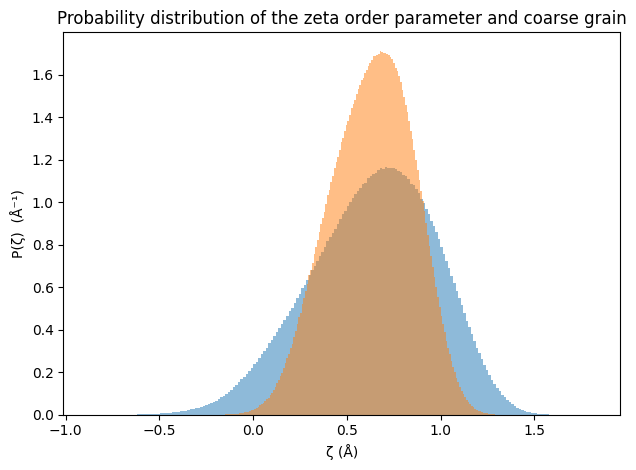

In [9]:
plt.hist(zeta_all.flatten(), bins=200, density=True, alpha=0.5, label='zeta')
plt.hist(zeta_cg_all.flatten(), bins=200, density=True, alpha=0.5, label='zeta_cg')
# ax.set(
#     xlabel="ζ (Å)",
#     ylabel="P(ζ)  (Å⁻¹)",
#     title="Probability distribution of the zeta order parameter",
# )
plt.xlabel("ζ (Å)")
plt.ylabel("P(ζ)  (Å⁻¹)")
plt.title("Probability distribution of the zeta order parameter and coarse grain")
ax.legend(fontsize=9)
plt.tight_layout()
# plt.savefig("zeta_distribution.png", dpi=300)
# plt.close()


then save the results as npy

In [ ]:
np.save("zeta_cg.npy", zeta_cg_all)
np.save("central_indices.npy", central_indices)
np.save("frames.npy", zop.frames)